# Analyzing Eddy-Covariance Footprints with the *footprints* Library

## Background: Flux Footprints and the Kljun Model

Eddy-covariance **flux footprints** quantify the surface area that contributes to a flux measurement at a tower. In other words, a footprint identifies the “source area” influencing the observed fluxes. Knowledge of footprints is crucial for interpreting flux data, especially in heterogeneous landscapes and for upscaling site measurements to regional scales. The footprint’s size and shape vary with wind, stability, and surface roughness – often covering on the order of 0.1–1 km² for \~80% of a flux, with dynamic upwind extents. Neglecting this can lead to mismatch between flux tower data and satellite-based estimates of land surface processes.

A widely used footprint model is the **Kljun et al. (2015)** parameterization (also known as FFP – *Flux Footprint Prediction*). This model provides a simple 2D analytical solution for footprint density based on many Lagrangian stochastic simulations. It improves upon earlier models by accounting for crosswind dispersion and surface roughness effects, and is valid across a broad range of stability regimes and measurement heights (essentially the entire boundary layer). The advantage of Kljun’s model is that it’s **computationally fast** – suitable for long time series and large datasets – while still agreeing well with more complex models.

The Python **`footprints`** library (also called *FluxFootprint*) is a full implementation of the Kljun et al. (2015) footprint parameterization. It provides vectorized calculations (using NumPy/xarray) to efficiently compute per-timestep footprints and aggregate them into “footprint climatologies”. In practical terms, this library lets you feed in time series of meteorological data from a flux tower and obtain the footprint function *f(x,y)* for each time or an overall sum. It also includes utilities for contouring source areas (e.g. 80% footprint contour) and exporting results for mapping. We will demonstrate how to use this library step-by-step, assuming the reader is new to footprint analysis.


## Using the Kljun Footprint Model with *footprints*

**1. Prepare input data:** The footprint model requires specific meteorological inputs for each time step. These typically include friction velocity (**USTAR**), crosswind turbulence (standard deviation of lateral velocity, **V\_SIGMA**), the Monin–Obukhov length (**MO\_LENGTH**, a measure of stability), wind direction (**WD**), and wind speed at measurement height (**WS**). Optionally you can provide canopy height and boundary-layer height if known, or use defaults. Make sure your data is in a pandas DataFrame with those columns (the library will internally rename them to the expected names `ustar`, `sigmav`, `ol`, `wind_dir`, `umean`). For example, if you have AmeriFlux data, you might start with a CSV of half-hourly observations:

In [10]:
import pandas as pd
# Load an AmeriFlux CSV file with necessary columns and a timestamp
df = pd.read_csv("./US-UTE_HH_202406241430_202409251400.csv", 
                 parse_dates=["datetime_start"],
                 )
df.iloc[0:100].to_csv(r"C:\Users\paulinkenbrandt\Desktop\US-UTE.csv")  # peek at columns: should have USTAR, V_SIGMA, MO_LENGTH, WD, WS, etc.

If needed, rename columns to match the expected names (USTAR, V\_SIGMA, MO\_LENGTH, WD, WS) as shown below. Ensure no obviously bad values remain (e.g. the library will drop or error on USTAR < 0.1 m·s⁻¹, invalid wind directions, etc., enforcing basic quality criteria).


**2. Instantiate the footprint model:** Using the `footprints` library, create an `FFPModel` (the class implementing Kljun’s model) with your DataFrame and desired parameters. Key parameters include the spatial domain and grid resolution for the footprint. For example, to cover ±1000 m around the tower at 2 m resolution, you’d set `domain=[-1000, 1000, -1000, 1000]` and `dx=dy=2` meters. You also specify the instrument height `inst_height` (e.g. tower height above ground) and canopy height `crop_height`. Here’s a typical setup:

In [ ]:
import os
import sys

# sys.path.insert(0, os.path.abspath("../../src"))
sys.path.insert(0, os.path.abspath("../../src"))  # adjust path as needed
from fluxfootprints import FFPClim
# Minimal renaming if needed (e.g., your file uses different column names)
df = df.rename(columns={"WD": "WD", "WS": "WS"})  # in this case already matches
df = df.iloc[0:100]
# Initialize the FFP model for the dataset
model = FFPClim(
    df,
    domain=[-700, 700, -700, 700],  # x_min, x_max, y_min, y_max (m)
    dx=5, dy=5,                         # grid resolution in x and y (m)
    inst_height=3.5,                    # instrument height above ground (m)
    crop_height=0.2,                    # canopy height (m)
    smooth_data=True                    # apply slight smoothing to the footprint
)


ImportError: cannot import name 'FFPClim' from 'fluxfootprints' (c:\Users\paulinkenbrandt\Documents\GitHub\footprints\src\fluxfootprints\__init__.py)


Under the hood, the model will preprocess the DataFrame (e.g. computing effective measurement height *z<sub>m</sub> = inst\_height – displacement*, roughness length z₀ = 0.123·h\_c, etc.) and set up a grid for calculations. It uses the Kljun et al. formulae (Eq. 14,17 in the paper) to compute the footprint density. The grid is centered at the tower (0,0) with the x-axis aligned to the mean wind direction for each time step. This means the footprint will be oriented properly for each wind direction.


**3. Run the model to compute footprints:** Once initialized, run the model to perform the calculations. You can either call `model.run()` to get the full climatology or step through individual methods. The simplest way is:

In [3]:
result = model.run()

2025-06-22 15:35:54,975 - FFPModel - INFO - Starting FFP model calculations...
2025-06-22 15:35:54,977 - FFPModel - INFO - Starting footprint calculation...
2025-06-22 15:35:54,995 - FFPModel - DEBUG - Rotated theta shape: (281, 281, 100)
2025-06-22 15:35:55,001 - FFPModel - DEBUG - Stability regime counts - Stable: 68, Unstable: 0, Neutral: 32
2025-06-22 15:35:55,003 - FFPModel - DEBUG - Initializing arrays with shape: x=281, y=281
2025-06-22 15:35:55,142 - FFPModel - DEBUG - xstar_ci_dummy shape: (281, 281, 100)
2025-06-22 15:35:55,151 - FFPModel - DEBUG - xstar_ci_dummy range: -inf to inf
2025-06-22 15:35:55,152 - FFPModel - DEBUG - Calculating crosswind-integrated footprint...
c:\Users\paulinkenbrandt\.conda\envs\py313\Lib\site-packages\xarray\core\computation.py:824: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)
2025-06-22 15:35:55,424 - FFPModel - DEBUG - x_star_modified shape: (281, 281, 100)
2025-06-22 15:35:55,432 - FFPModel - DEBUG - x_star_mod

In [4]:
print(result["footprint_2d"].shape)  # e.g. (1001, 1001) for a 2000 m × 2000 m domain at 2 m res

(281, 281, 100)


**4. Visualize the footprint:** The library provides plotting utilities to visualize footprint results. For instance, you can plot contour lines enclosing a given percentage of source contribution. To plot the 80% source area contour (a common metric of footprint extent), simply do:


2025-06-22 15:37:44,018 - FFPModel - DEBUG - Domain shapes - x: 281, y: 281
2025-06-22 15:37:44,020 - FFPModel - DEBUG - Footprint climatology shape: (281, 281)
2025-06-22 15:37:44,022 - FFPModel - DEBUG - Footprint climatology stats - min: 0.0, max: 0.004861026649227599


(-100.0, 100.0)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


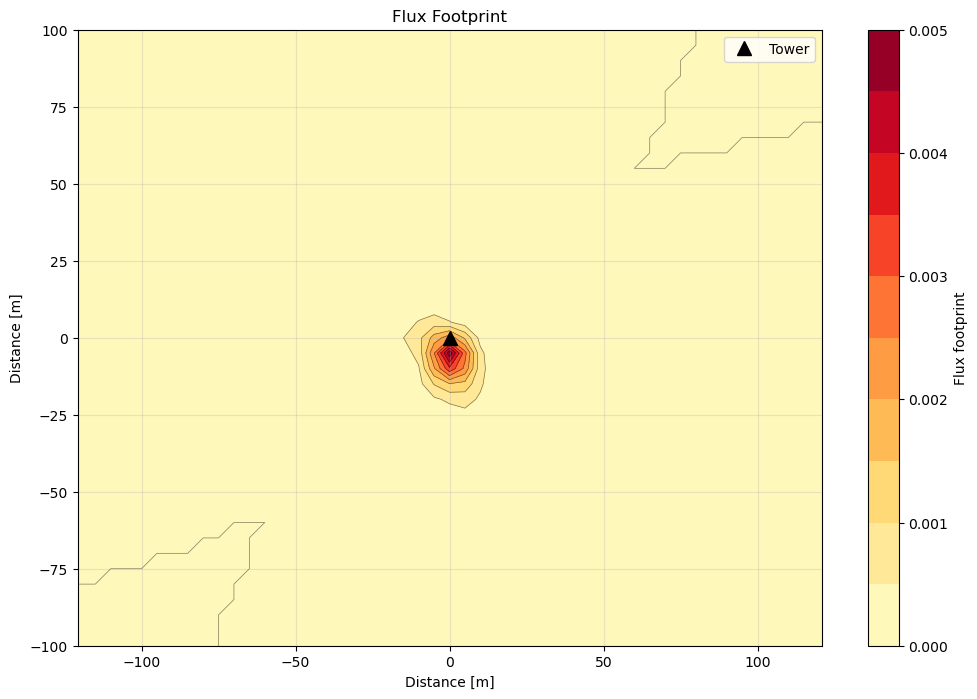

In [7]:
import matplotlib.pyplot as plt

model.plot_footprint()
plt.xlim(-100, 100)
plt.ylim(-100, 100)


This will produce a contour plot (e.g. 10%, 20%, … 80% contours) with the tower at the origin. The highest footprint density is typically near the tower and upwind of it, and the contours elongate in the upwind direction (see example concept in Kljun *et al.*). The plot gives an intuitive sense of how far upwind 80% of the flux is coming from – for example, an 80% footprint distance *x*₈₀ of a few hundred meters under convective conditions.

*Note:* The library’s default coordinate system is tower-centric (x-axis aligned with North=0° and increasing clockwise). Internally, it rotates coordinates by wind direction for each time step. The `fclim_2d` output is essentially a “footprint climatology” raster in tower coordinates (x,y in meters). You could export this to geospatial coordinates if the tower location is known, but more on that later.

## From Footprints to ET: Using AmeriFlux Data and Visualizing Time Series

Once you can compute footprints, a powerful application is to combine them with other spatial data – for example, to compare tower-measured **evapotranspiration (ET)** with satellite-based ET. The idea is to weight the spatial ET data by the footprint (which acts like a weighting function) to get the effective ET that the tower “sees”. We can do this on a **daily basis** by calculating daily footprint distributions and integrating them with daily ET maps.

**1. Hourly footprints for each day:** The footprints library includes high-level functions to automate this process. For instance, `fluxfootprints.calc_hourly_ffp(station, startdate, ...)` will fetch the meteorological data for a given AmeriFlux station and compute hourly footprints for each day, saving them as GeoTIFF files (each file containing hourly footprint rasters as bands). You can specify station by its AmeriFlux ID (e.g., `"US-UTW"`) and a start date. This function uses the Kljun model under the hood for each hour between \~06:00–20:00 (daytime hours). For example:


In [9]:
from fluxfootprints import calc_hourly_ffp
calc_hourly_ffp("US-UTE", startdate="2021-01-01", out_dir="output/USUTE/",
                config_path="../../data/station_config", dx=5.0, origin_d=500.0)

No data for 6:00, skipping.
No data for 7:00, skipping.
No data for 8:00, skipping.
No data for 9:00, skipping.
No data for 10:00, skipping.
No data for 11:00, skipping.
No data for 12:00, skipping.
No data for 13:00, skipping.
No data for 14:00, skipping.
No data for 15:00, skipping.
Error computing footprint for hour 16: FFPModel.__init__() missing 1 required positional argument: 'df'
Error computing footprint for hour 17: FFPModel.__init__() missing 1 required positional argument: 'df'
Error computing footprint for hour 18: FFPModel.__init__() missing 1 required positional argument: 'df'
No data for 6:00, skipping.
No data for 7:00, skipping.
No data for 8:00, skipping.
No data for 9:00, skipping.
No data for 10:00, skipping.
No data for 11:00, skipping.
No data for 12:00, skipping.
No data for 13:00, skipping.
No data for 14:00, skipping.
No data for 15:00, skipping.
Error computing footprint for hour 16: FFPModel.__init__() missing 1 required positional argument: 'df'
Error comput